In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

tf.keras.backend.clear_session()

2026-04-04 15:11:31.190954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775315491.411275      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775315491.476842      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775315492.001221      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775315492.001262      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775315492.001265      55 computation_placer.cc:177] computation placer alr

In [2]:
augmented_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Augmented_Dataset"
original_dir  = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 12
EPOCHS_STAGE2 = 18
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

In [3]:
class_names = sorted([
    d for d in os.listdir(augmented_dir)
    if os.path.isdir(os.path.join(augmented_dir, d))
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']
Number of classes: 3


In [4]:
def get_image_paths_and_labels(data_dir, class_names):
    file_paths, labels = [], []
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(valid_ext):
                file_paths.append(os.path.join(class_path, file_name))
                labels.append(idx)

    return file_paths, labels

In [5]:
train_paths, train_labels = get_image_paths_and_labels(augmented_dir, class_names)
original_paths, original_labels = get_image_paths_and_labels(original_dir, class_names)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    original_paths,
    original_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=original_labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Training images: 10185
Validation images: 1018
Test images: 1019


In [6]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}
print("Class Weights:", class_weights)

Class Weights: {0: 0.6287037037037037, 1: 2.524163568773234, 2: 0.9869186046511628}


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.12),
    layers.RandomBrightness(0.12),
    layers.RandomTranslation(0.06, 0.06),
], name="data_augmentation")

I0000 00:00:1775315518.473974      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775315518.479928      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label


def prepare_resnet(image, label):
    return resnet_preprocess(image), label


def prepare_densenet(image, label):
    return densenet_preprocess(image), label

In [9]:
def create_branch_dataset(paths, labels, preprocess_fn, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


def make_fusion_dataset(paths, labels, training=False):
    resnet_ds = create_branch_dataset(paths, labels, prepare_resnet, training=training)
    densenet_ds = create_branch_dataset(paths, labels, prepare_densenet, training=training)

    fusion_ds = tf.data.Dataset.zip((resnet_ds, densenet_ds))
    fusion_ds = fusion_ds.map(
        lambda a, b: ((a[0], b[0]), a[1]),
        num_parallel_calls=AUTOTUNE
    )
    return fusion_ds.prefetch(AUTOTUNE)

In [10]:
train_ds = make_fusion_dataset(train_paths, train_labels, training=True)
val_ds   = make_fusion_dataset(val_paths, val_labels, training=False)
test_ds  = make_fusion_dataset(test_paths, test_labels, training=False)

print("Fusion datasets created.")

Fusion datasets created.


In [11]:
resnet_input = layers.Input(shape=(224, 224, 3), name="resnet_input")
densenet_input = layers.Input(shape=(224, 224, 3), name="densenet_input")

# ResNet50 branch
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
resnet_base.trainable = False

x1 = resnet_base(resnet_input, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x1)
x1 = layers.Dropout(0.25)(x1)

# DenseNet121 branch
densenet_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
densenet_base.trainable = False

x2 = densenet_base(densenet_input, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x2)
x2 = layers.Dropout(0.25)(x2)

# Fusion head
fusion = layers.Concatenate(name="late_fusion_concat")([x1, x2])
fusion = layers.BatchNormalization()(fusion)
fusion = layers.Dense(384, activation="relu", kernel_regularizer=l2(1e-4))(fusion)
fusion = layers.Dropout(0.30)(fusion)
fusion = layers.Dense(192, activation="relu", kernel_regularizer=l2(1e-4))(fusion)
fusion = layers.Dropout(0.20)(fusion)

output = layers.Dense(num_classes, activation="softmax", name="output")(fusion)

model = Model(
    inputs=[resnet_input, densenet_input],
    outputs=output,
    name="Pipeline7_ResNet50_DenseNet121_LateFusion_Fixed"
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Pipeline7_ResNet50_DenseNet121_LateFusion_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resnet_input        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_input      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ resnet_input[0][… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ densenet_input[0… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    262,400 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 512)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ late_fusion_conc… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 384)       │    196,992 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 192)       │     73,920 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 192)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        579 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,697,987 (120.92 MB)

 Trainable params: 1,065,603 (4.06 MB)

 Non-trainable params: 30,632,384 (116.85 MB)

In [12]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [13]:
callbacks_stage1 = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "pipeline7_stage1_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

In [14]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1
)

Epoch 1/12


I0000 00:00:1775315547.182312     127 service.cc:152] XLA service 0x7cd824008be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775315547.182354     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775315547.182359     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775315554.719534     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775315573.023015     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.5752 - loss: 1.1193
Epoch 1: val_loss improved from inf to 0.50798, saving model to pipeline7_stage1_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 312s 834ms/step - accuracy: 0.5755 - loss: 1.1187 - val_accuracy: 0.8919 - val_loss: 0.5080 - learning_rate: 1.0000e-04
Epoch 2/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.8220 - loss: 0.6403
Epoch 2: val_loss improved from 0.50798 to 0.41430, saving model to pipeline7_stage1_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 211s 658ms/step - accuracy: 0.8220 - loss: 0.6403 - val_accuracy: 0.9185 - val_loss: 0.4143 - learning_rate: 1.0000e-04
Epoch 3/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.8540 - loss: 0.5485
Epoch 3: val_loss improved from 0.41430 to 0.35845, saving model to pipeline7_stage1_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 211s 659ms/step - accuracy: 0.8540 - loss: 0.5485 - val_accuracy: 0.9322 - val_loss: 0.3584 - learning_rate: 1.0000e-04
Epoch 4/12
319/3

In [15]:
model.load_weights("pipeline7_stage1_best.keras")

resnet_base.trainable = True
densenet_base.trainable = True

for layer in resnet_base.layers[:-60]:
    layer.trainable = False

for layer in densenet_base.layers[:-60]:
    layer.trainable = False

for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

for layer in densenet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("ResNet trainable layers:", sum(layer.trainable for layer in resnet_base.layers))
print("DenseNet trainable layers:", sum(layer.trainable for layer in densenet_base.layers))

ResNet trainable layers: 42
DenseNet trainable layers: 43


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_stage2 = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "pipeline7_stage2_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/18
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.9181 - loss: 0.3481
Epoch 1: val_loss improved from inf to 0.27104, saving model to pipeline7_stage2_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 320s 845ms/step - accuracy: 0.9181 - loss: 0.3481 - val_accuracy: 0.9519 - val_loss: 0.2710 - learning_rate: 5.0000e-06
Epoch 2/18
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.9247 - loss: 0.3285
Epoch 2: val_loss improved from 0.27104 to 0.26931, saving model to pipeline7_stage2_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 230s 720ms/step - accuracy: 0.9247 - loss: 0.3285 - val_accuracy: 0.9558 - val_loss: 0.2693 - learning_rate: 5.0000e-06
Epoch 3/18
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.9307 - loss: 0.3210
Epoch 3: val_loss improved from 0.26931 to 0.25589, saving model to pipeline7_stage2_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 232s 724ms/step - accuracy: 0.9307 - loss: 0.3210 - val_accuracy: 0.9568 - val_loss: 0.2559 - learning_rate: 5.0000e-06
Epoch

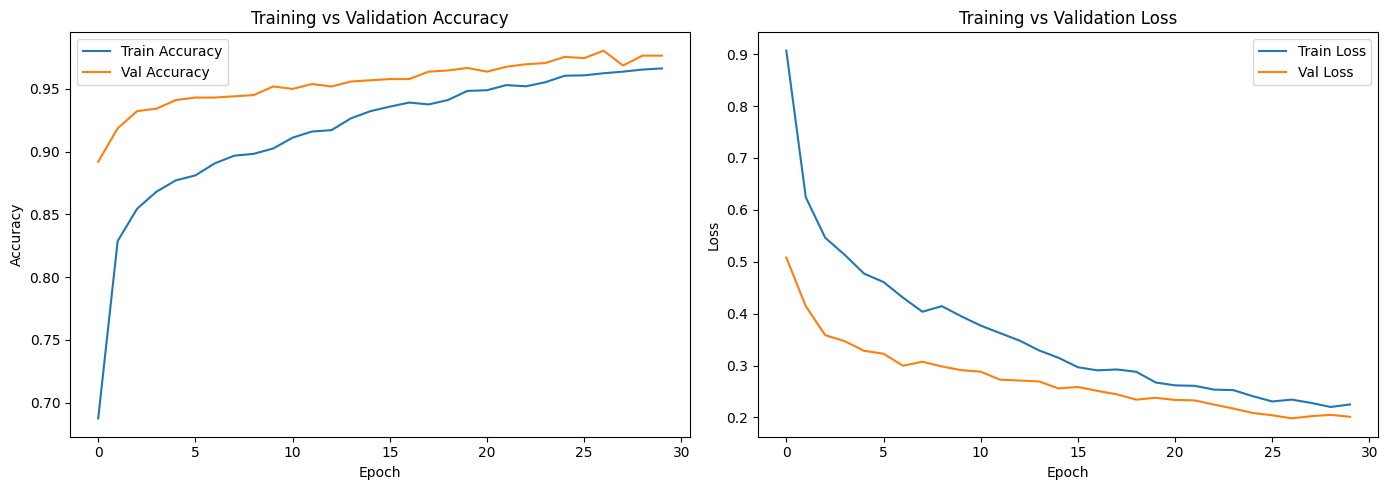

In [17]:
model.load_weights("pipeline7_stage2_best.keras")

history = {}
for key in history_stage1.history.keys():
    history[key] = history_stage1.history[key] + history_stage2.history[key]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 756ms/step - accuracy: 0.9589 - loss: 0.2380
Test Loss: 0.2134394496679306
Test Accuracy: 0.9735034108161926
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 632ms/step
              precision    recall  f1-score   support

Healthy_Leaf       0.99      0.96      0.98       540
    Leaf_Rot       0.99      0.97      0.98       135
   Leaf_Spot       0.94      0.99      0.97       344

    accuracy                           0.97      1019
   macro avg       0.97      0.98      0.97      1019
weighted avg       0.97      0.97      0.97      1019

Weighted F1: 0.9736123525383554
Macro F1: 0.9746189196154647


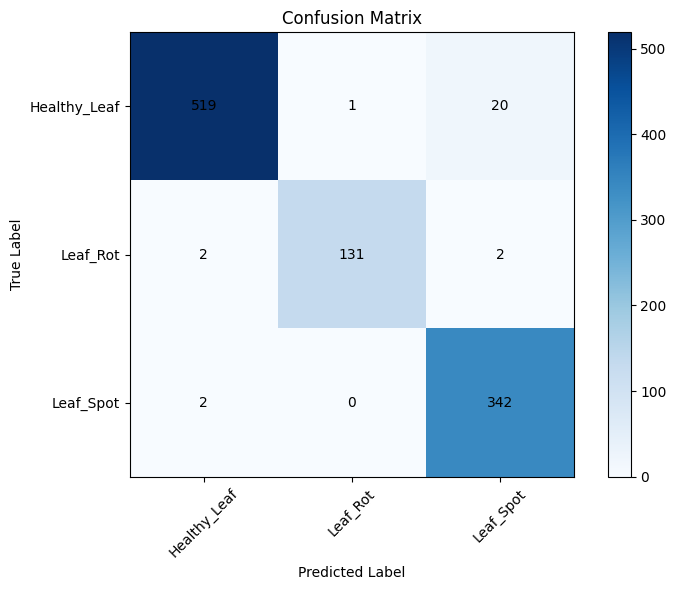

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 464ms/step
Saved model and prediction files.


In [18]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

model.save("pipeline7_final_fixed.keras")

val_pred_probs = model.predict(val_ds, verbose=1)
np.save("pipeline7_val_probs.npy", val_pred_probs)
np.save("pipeline7_test_probs.npy", y_pred_probs)
np.save("pipeline7_val_labels.npy", np.array(val_labels))
np.save("pipeline7_test_labels.npy", y_true)

print("Saved model and prediction files.")